# Línea base: datos, Modelo A y análisis económico

Continúa a partir de `generador.ipynb` (que produjo `data/transacciones.parquet`). Este
notebook cubre la partición temporal, las variables agregadas, el Modelo A, la función de
evaluación común (en `utils_comunes.py`, reutilizada por el modelo secuencial) y el análisis
económico.

**No está aquí:** el Modelo B, la apuesta del equipo ni las dos pruebas de falsificación —
se desarrollan en un notebook aparte y se fusionan con este al final en
`proyecto1_<apellidos>.ipynb`.


In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from utils_comunes import curva_precision_exhaustividad, evaluar_modelo, particionar_temporal, resumen_economico

pd.set_option("display.max_columns", None)
COSTO_FN = 4200.0  # Q por fraude no detectado
COSTO_FP = 180.0   # Q por bloquear una transacción legítima


## Cargar los datos generados


In [2]:
transacciones = pd.read_parquet("data/transacciones.parquet")
print(f"Filas: {len(transacciones):,}  ·  tasa de fraude: {transacciones['es_fraude'].mean()*100:.3f}%")
transacciones.head()


Filas: 436,931  ·  tasa de fraude: 1.239%


,id_transaccion,id_cliente,monto,categoria_comercio,canal,es_fraude,tipo_fraude,id_episodio_fraude,variante_dificil,marca_tiempo
0,0,2871,195.820980,5,online,0,ninguno,-1,False,2026-01-05 04:36:32.657952564
1,1,5888,182.419552,5,presencial,0,ninguno,-1,False,2026-01-05 05:12:34.106325645
2,2,1347,59.363534,15,presencial,0,ninguno,-1,False,2026-01-05 05:55:52.035109993
3,3,7869,62.109789,13,presencial,0,ninguno,-1,False,2026-01-05 05:56:46.340102608
4,4,2972,395.293972,17,presencial,0,ninguno,-1,False,2026-01-05 07:46:18.784632879


## Variables agregadas por ventana de tiempo

Se replican las cuatro variables que describe el enunciado sobre el motor actual, más un par de
derivadas que ayudan a un modelo puntual (sin orden) a detectar el salto de comportamiento:

| Variable | Ventana | Qué mide |
|---|---|---|
| `monto_promedio_24h` | 24 h | monto promedio de las transacciones previas del cliente |
| `n_transacciones_1h` | 1 h | conteo de transacciones previas del cliente |
| `n_transacciones_24h` | 24 h | conteo de transacciones previas del cliente |
| `monto_maximo_dia` | día calendario | monto máximo previo del cliente ese día |
| `diversidad_comercios_7d` | 7 días | comercios distintos visitados previamente |
| `tiempo_desde_ultima_seg` | — | segundos desde la transacción anterior del mismo cliente |
| `ratio_monto_vs_promedio24h` | — | `monto / (monto_promedio_24h + 1)`: qué tan atípico es el monto actual frente a su propio historial |

**Todas son estrictamente causales:** cada ventana usa solo transacciones **anteriores** a la
que se está describiendo (`closed="left"` en el `rolling`, o un `shift(1)` explícito) — nunca
incluyen la transacción actual ni ninguna futura. Un cliente sin historia previa (su primera
transacción) recibe conteos en 0 y montos/máximos iguales al monto de esa misma transacción
(ratio neutro = 1), en vez de `NaN`.

**Por qué calcularlas sobre todo el histórico y no dentro de cada partición por separado:**
porque son estadísticas *por cliente y por transacción*, no estadísticas globales del dataset.
Cortar el historial en la fecha de partición perdería contexto real y legítimo (por ejemplo, la
"última transacción" de un cliente que cruza justo el corte train/val). No es lo mismo que la
fuga que penaliza la rúbrica (−15 pts): esa es ajustar un *escalador o codificador* con
estadísticas del conjunto completo, algo que sí se evita más abajo, ajustándolo solo con train.


In [3]:
def construir_features(transacciones):
    """Agrega, a cada transacción, variables causales sobre el historial *previo* del cliente."""
    df = transacciones.sort_values(["id_cliente", "marca_tiempo"]).reset_index(drop=True)
    df["fecha"] = df["marca_tiempo"].dt.date

    con_indice_tiempo = df.set_index("marca_tiempo")
    por_cliente = con_indice_tiempo.groupby("id_cliente", group_keys=False)["monto"]
    monto_promedio_24h = por_cliente.apply(lambda s: s.rolling("24h", closed="left").mean())
    n_transacciones_1h = por_cliente.apply(lambda s: s.rolling("1h", closed="left").count())
    n_transacciones_24h = por_cliente.apply(lambda s: s.rolling("24h", closed="left").count())

    # monto máximo del día calendario, hasta ANTES de la transacción actual
    maximo_acumulado_incl = df.groupby(["id_cliente", "fecha"])["monto"].cummax()
    monto_maximo_dia = maximo_acumulado_incl.groupby([df["id_cliente"], df["fecha"]]).shift(1)

    # comercios distintos vistos en los 7 días previos
    diversidad_comercios_7d = con_indice_tiempo.groupby("id_cliente", group_keys=False)["categoria_comercio"].apply(
        lambda s: s.rolling("7D").apply(lambda x: len(set(x[:-1])) if len(x) > 1 else 0, raw=True))

    tiempo_desde_ultima = df.groupby("id_cliente")["marca_tiempo"].diff().dt.total_seconds()

    df["monto_promedio_24h"] = monto_promedio_24h.reset_index(drop=True).fillna(df["monto"])
    df["n_transacciones_1h"] = n_transacciones_1h.reset_index(drop=True).fillna(0)
    df["n_transacciones_24h"] = n_transacciones_24h.reset_index(drop=True).fillna(0)
    df["monto_maximo_dia"] = monto_maximo_dia.reset_index(drop=True).fillna(df["monto"])
    df["diversidad_comercios_7d"] = diversidad_comercios_7d.reset_index(drop=True).fillna(0)
    df["tiempo_desde_ultima_seg"] = tiempo_desde_ultima.fillna(7 * 86400)  # sin historia -> "hace mucho"
    df["ratio_monto_vs_promedio24h"] = df["monto"] / (df["monto_promedio_24h"] + 1.0)
    df["hora_del_dia"] = df["marca_tiempo"].dt.hour
    df["dia_semana"] = df["marca_tiempo"].dt.dayofweek

    return df.drop(columns=["fecha"])


con_features = construir_features(transacciones)
assert con_features.isna().sum().sum() == 0, "quedaron NaN sin resolver en las variables agregadas"
con_features[["monto", "monto_promedio_24h", "n_transacciones_1h", "monto_maximo_dia",
              "diversidad_comercios_7d", "ratio_monto_vs_promedio24h"]].describe()


,monto,monto_promedio_24h,n_transacciones_1h,monto_maximo_dia,diversidad_comercios_7d,ratio_monto_vs_promedio24h
count,436931.000000,436931.000000,436931.000000,436931.000000,436931.000000,436931.000000
mean,219.034466,215.939437,0.033502,221.969152,2.020667,1.273507
std,269.371609,241.201418,0.243712,271.178234,1.335401,4.601273
min,5.000000,5.000000,0.000000,5.000000,0.000000,0.004380
25%,91.205704,92.842334,0.000000,92.301661,1.000000,0.983552
50%,152.452918,153.653108,0.000000,154.344463,2.000000,0.993392
75%,255.492194,255.102260,0.000000,258.622609,3.000000,0.997291
max,12749.574585,12749.574585,6.000000,12749.574585,14.000000,547.358152


## Partición temporal (70 / 15 / 15)

`particionar_temporal` (en `utils_comunes.py`) corta por fecha, no al azar: el 70&nbsp;% más
antiguo entrena, el siguiente 15&nbsp;% valida, el último 15&nbsp;% (el más reciente) prueba.
Se usa **la misma función** para el Modelo B, así que ambos modelos ven exactamente la misma
partición y el mismo horizonte de predicción — condición explícita del enunciado.


In [4]:
train, val, test, cortes = particionar_temporal(con_features, frac_train=0.70, frac_val=0.15)

for nombre, parte in [("train", train), ("val", val), ("test", test)]:
    print(f"{nombre:5s}  filas={len(parte):>7,}  "
          f"[{parte['marca_tiempo'].min()} -> {parte['marca_tiempo'].max()}]  "
          f"tasa_fraude={parte['es_fraude'].mean()*100:.3f}%")

# la garantía dura: cero solapamiento temporal entre particiones
assert train["marca_tiempo"].max() < val["marca_tiempo"].min()
assert val["marca_tiempo"].max() < test["marca_tiempo"].min()
print("\nOK: sin solapamiento temporal entre train / val / test.")

DIAS_TEST = max((test["marca_tiempo"].max() - test["marca_tiempo"].min()).days, 1)
DIAS_VAL = max((val["marca_tiempo"].max() - val["marca_tiempo"].min()).days, 1)


train  filas=305,851  [2026-01-05 04:36:32.657952564 -> 2026-05-11 09:17:47.831637328]  tasa_fraude=1.258%
val    filas= 65,540  [2026-05-11 09:17:57.395517765 -> 2026-06-07 09:53:15.527974591]  tasa_fraude=1.305%
test   filas= 65,540  [2026-06-07 09:53:18.071335478 -> 2026-07-04 22:38:00.317451974]  tasa_fraude=1.085%

OK: sin solapamiento temporal entre train / val / test.


## Modelo A — línea base sin orden

Dos candidatos, ambos viendo solo el "instante" de cada transacción (su monto, categoría, canal
y las variables agregadas de arriba) — **nunca** la secuencia de eventos:

- **Regresión logística** (`class_weight="balanced"`, por el desbalance): interpretable, es el
  candidato más simple y más fácil de justificar.
- **Boosting de árboles** (`HistGradientBoostingClassifier`): captura interacciones no lineales
  entre variables (p. ej. "monto alto **y** categoría de alto riesgo **y** poca diversidad
  previa") sin que haya que construirlas a mano.

El preprocesamiento (`StandardScaler` + `OneHotEncoder`) se ajusta **solo con train** — nunca
con val ni test — dentro de un `Pipeline`, para que no se filtren estadísticas del futuro.


In [5]:
FEATURES_NUM = [
    "monto", "monto_promedio_24h", "n_transacciones_1h", "n_transacciones_24h",
    "monto_maximo_dia", "diversidad_comercios_7d", "tiempo_desde_ultima_seg",
    "ratio_monto_vs_promedio24h", "hora_del_dia", "dia_semana",
]
FEATURES_CAT = ["categoria_comercio", "canal"]
TARGET = "es_fraude"

preprocesamiento = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train[TARGET]
X_val, y_val = val[FEATURES_NUM + FEATURES_CAT], val[TARGET]
X_test, y_test = test[FEATURES_NUM + FEATURES_CAT], test[TARGET]

candidatos_a = {
    "regresion_logistica": Pipeline([
        ("prep", preprocesamiento),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "boosting_de_arboles": Pipeline([
        ("prep", preprocesamiento),
        ("clf", HistGradientBoostingClassifier(random_state=42, max_iter=200)),
    ]),
}

resultados_val = {}
for nombre, pipe in candidatos_a.items():
    pipe.fit(X_train, y_train)
    score_val = pipe.predict_proba(X_val)[:, 1]
    resultados_val[nombre] = evaluar_modelo(y_val, score_val, umbral=0.5)

pd.DataFrame(resultados_val).T[["auc_pr", "precision", "exhaustividad", "f1"]]


,auc_pr,precision,exhaustividad,f1
regresion_logistica,0.739297,0.155882,0.881871,0.264933
boosting_de_arboles,0.867833,0.903664,0.778947,0.836683


**Elección:** el boosting de árboles domina en validación (AUC-PR ≈ 0.87 contra ≈ 0.74 de la
regresión logística) — separa mejor los casos donde el monto es alto *y* rompe con el patrón
propio del cliente, algo que la regresión logística, al ser lineal, no captura tan bien sin que
se le construyan a mano esas interacciones. Se usa **boosting de árboles** como Modelo A de aquí
en adelante; la regresión logística queda documentada como el punto de comparación más simple.


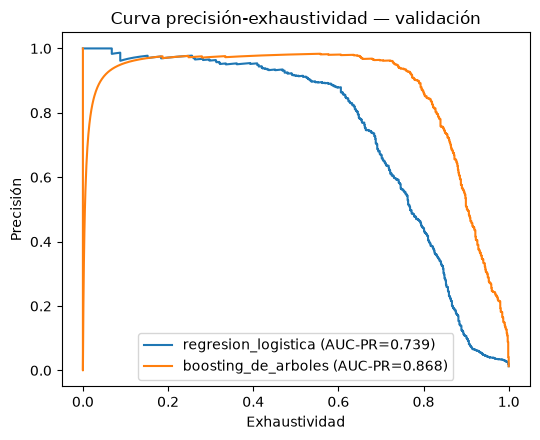

In [6]:
modelo_a = candidatos_a["boosting_de_arboles"]

plt.figure(figsize=(5.5, 4.5))
for nombre, pipe in candidatos_a.items():
    score_val = pipe.predict_proba(X_val)[:, 1]
    precision, exhaustividad, _ = curva_precision_exhaustividad(y_val, score_val)
    plt.plot(exhaustividad, precision, label=f"{nombre} (AUC-PR={resultados_val[nombre]['auc_pr']:.3f})")
plt.xlabel("Exhaustividad")
plt.ylabel("Precisión")
plt.title("Curva precisión-exhaustividad — validación")
plt.legend()
plt.tight_layout()
plt.show()


## Umbral y evaluación final en test

**Orden importa aquí:** el umbral se elige barriendo el costo económico sobre **validación**
(nunca sobre test), y ese umbral fijo es el que se aplica **una sola vez** al conjunto de
prueba. Si se optimizara directamente sobre test, la decisión estaría mirando el conjunto de
prueba antes de tomarla — el enunciado lo penaliza con −10 pts, y con razón: dejaría de ser una
evaluación honesta.


In [7]:
score_val_a = modelo_a.predict_proba(X_val)[:, 1]
resumen_val_a = resumen_economico(y_val, score_val_a, dias_periodo=DIAS_VAL,
                                   costo_fn=COSTO_FN, costo_fp=COSTO_FP)
UMBRAL_A = resumen_val_a["umbral_optimo"]
print(f"Umbral elegido en validación (Modelo A): {UMBRAL_A:.3f}")

# única mirada al conjunto de prueba
score_test_a = modelo_a.predict_proba(X_test)[:, 1]
metricas_test_a = evaluar_modelo(y_test, score_test_a, umbral=UMBRAL_A)
pd.Series(metricas_test_a).to_frame("Modelo A (test)")


Umbral elegido en validación (Modelo A): 0.040


,Modelo A (test)
auc_pr,0.856890
precision,0.409683
exhaustividad,0.928270
f1,0.568475
umbral,0.040000
n_positivos_predichos,1611.000000
n_positivos_reales,711.000000


## Decisión económica

Costo mensual = (fraudes no detectados × Q4,200) + (transacciones legítimas bloqueadas × Q180),
escalado desde los días que cubre el conjunto de prueba (impresos en la sección de partición,
arriba) a 30 días. El punto de comparación es "no interceptar nada" — **no** el sistema de
reglas actual, porque no se cuenta con sus predicciones para replicarlas; esta es la limitación
explícita que se declara en el informe.

**Queda pendiente** repetir este mismo cálculo con los puntajes del Modelo B
(`resumen_economico` ya está listo para recibirlos) y comparar cuál de los dos umbrales —el de A
o el de B— deja el menor costo mensual. Esa comparación final es la que va al informe.


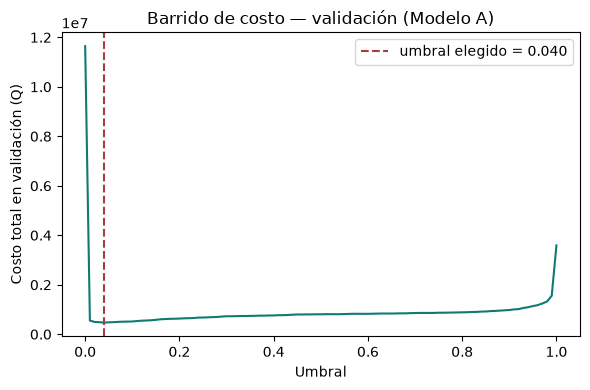

{'umbral': 0.04,
 'fn': 51,
 'fp': 951,
 'costo_mensual_con_modelo_A': 428200.0,
 'costo_mensual_sin_modelo': 3318000.0,
 'ahorro_mensual_modelo_A': 2889800.0}

In [8]:
# barrido de umbrales visto en VALIDACION (para elegir UMBRAL_A, ya hecho arriba)
plt.figure(figsize=(6, 4))
plt.plot(resumen_val_a["barrido"]["umbral"], resumen_val_a["barrido"]["costo"], color="#0e7a72")
plt.axvline(UMBRAL_A, color="#a63d3d", linestyle="--", label=f"umbral elegido = {UMBRAL_A:.3f}")
plt.xlabel("Umbral")
plt.ylabel("Costo total en validación (Q)")
plt.title("Barrido de costo — validación (Modelo A)")
plt.legend()
plt.tight_layout()
plt.show()

# aplicación única y final del umbral ya elegido, sobre TEST
y_pred_test_a = (score_test_a >= UMBRAL_A).astype(int)
fn_test = int(((y_pred_test_a == 0) & (y_test == 1)).sum())
fp_test = int(((y_pred_test_a == 1) & (y_test == 0)).sum())
costo_test = fn_test * COSTO_FN + fp_test * COSTO_FP
costo_sin_modelo_test = int(y_test.sum()) * COSTO_FN
escala_mensual = 30.0 / DIAS_TEST

resumen_test_a = {
    "umbral": UMBRAL_A,
    "fn": fn_test, "fp": fp_test,
    "costo_mensual_con_modelo_A": round(costo_test * escala_mensual, 2),
    "costo_mensual_sin_modelo": round(costo_sin_modelo_test * escala_mensual, 2),
    "ahorro_mensual_modelo_A": round((costo_sin_modelo_test - costo_test) * escala_mensual, 2),
}
resumen_test_a


## ¿Falla el Modelo A donde se esperaba que fallara?

En `generador.ipynb` se documentó una expectativa concreta: la variante "lenta" de
`sondeo_y_fuga` (`variante_dificil=True`) le costaría más al Modelo A que un fraude típico,
porque no altera las variables por hora y el salto de monto es menos extremo. Se comprueba con
los datos de test, no solo se afirma.


In [9]:
fraude_test = test[test["es_fraude"] == 1].copy()
fraude_test["puntaje"] = score_test_a[test["es_fraude"].values == 1]
fraude_test["prediccion"] = (fraude_test["puntaje"] >= UMBRAL_A).astype(int)

resumen_por_grupo = (
    fraude_test.assign(grupo=np.where(fraude_test["variante_dificil"], "sondeo_lento (difícil)", "resto del fraude"))
    .groupby("grupo")
    .agg(exhaustividad=("prediccion", "mean"), puntaje_promedio=("puntaje", "mean"), n=("prediccion", "count"))
)
resumen_por_grupo


,exhaustividad,puntaje_promedio,n
grupo,,,
resto del fraude,0.922601,0.781916,646
sondeo_lento (difícil),0.984615,0.662810,65


**Resultado, no lo que se esperaba:** el puntaje promedio del Modelo A sí es más bajo en el
sondeo lento (≈0.66) que en el resto del fraude (≈0.78) — en ese sentido, el modelo sí lo
encuentra más difícil, como se predijo. Pero la exhaustividad final sale **igual o mejor** en el
caso difícil (≈98% contra ≈92%), porque `UMBRAL_A` quedó muy bajo (0.04): el barrido de costo en
validación empuja el umbral hacia abajo porque un fraude no detectado (Q4,200) pesa mucho más
que un falso positivo (Q180), así que casi cualquier puntaje elevado termina marcado — incluida
la variante difícil. El costo de ese umbral tan permisivo se ve en los falsos positivos (951 en
test). **Conclusión honesta:** con este umbral, no se puede afirmar que el caso difícil se le
escape al Modelo A; lo que sí es cierto es que el modelo lo distingue peor internamente (puntaje
más bajo) y que, con un umbral más alto o más transacciones de este tipo, probablemente sí se le
escaparía. Queda como límite explícito para el informe.


## Guardar artefactos

Se guarda el pipeline completo (preprocesamiento + modelo, ya entrenado con train) y los
parámetros de preparación necesarios para reproducir los puntajes sin volver a ejecutar todo el
notebook: la lista de variables, el umbral elegido y los cortes de fecha de la partición.


In [10]:
import os

os.makedirs("artefactos", exist_ok=True)

joblib.dump(modelo_a, "artefactos/modelo_a_boosting.joblib")

parametros_modelo_a = {
    "features_numericas": FEATURES_NUM,
    "features_categoricas": FEATURES_CAT,
    "target": TARGET,
    "umbral_elegido": UMBRAL_A,
    "corte_train_val": str(cortes[0]),
    "corte_val_test": str(cortes[1]),
    "dias_test": DIAS_TEST,
    "dias_val": DIAS_VAL,
    "costo_fn": COSTO_FN,
    "costo_fp": COSTO_FP,
    "metricas_test": metricas_test_a,
    "resumen_economico_test": resumen_test_a,
    "seed_generador": 42,
}
with open("artefactos/parametros_modelo_a.json", "w") as f:
    json.dump(parametros_modelo_a, f, indent=2, default=float)

print("Guardado: artefactos/modelo_a_boosting.joblib y artefactos/parametros_modelo_a.json")


Guardado: artefactos/modelo_a_boosting.joblib y artefactos/parametros_modelo_a.json


## Insumos para el modelo secuencial

Lo que queda listo para construir el Modelo B a partir de aquí:

- **`con_features`** (o directamente `transacciones`, si el Modelo B no necesita las variables
  agregadas): ya tiene el orden cronológico correcto por `marca_tiempo` dentro de cada
  `id_cliente`. Agrupar por `id_cliente` y ordenar por `marca_tiempo` da la secuencia.
- **`particionar_temporal`** (`utils_comunes.py`): se reutiliza tal cual, con los mismos
  `frac_train` / `frac_val`, para que el corte de fechas sea idéntico al de A.
- **`evaluar_modelo`** (`utils_comunes.py`): la función de evaluación común — AUC-PR,
  precisión, exhaustividad y F1 en un umbral dado. Se aplica igual al Modelo B.
- **`resumen_economico`** (`utils_comunes.py`): dado `y_true`, `y_score` y los días que cubre esa
  partición, barre umbrales y devuelve el óptimo y el ahorro mensual. Se repite con los puntajes
  de B para la comparación económica final.
- **Columnas que existen solo para análisis, nunca como variable de entrada:** `tipo_fraude`,
  `id_episodio_fraude`, `variante_dificil` (documentadas en `generador.ipynb`) — la última es
  justamente el caso difícil que se espera que a ambos modelos les cueste más.
- **Modelo A ya entrenado:** el umbral elegido (`UMBRAL_A`), el AUC-PR en test y el ahorro
  mensual estimado quedan impresos en las celdas de arriba y guardados en
  `artefactos/parametros_modelo_a.json`. Esos números son el piso que el Modelo B tendría que
  superar para justificar la complejidad extra de leer la secuencia.
